In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('AAPL_data.csv')

In [3]:
data.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,12-12-1980,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,15-12-1980,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,16-12-1980,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,17-12-1980,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,18-12-1980,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11084 entries, 0 to 11083
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11084 non-null  object 
 1   Adj Close  11084 non-null  float64
 2   Close      11084 non-null  float64
 3   High       11084 non-null  float64
 4   Low        11084 non-null  float64
 5   Open       11084 non-null  float64
 6   Volume     11084 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 606.3+ KB
None


In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
print(data['Date'])

0       1980-12-12
1       1980-12-15
2       1980-12-16
3       1980-12-17
4       1980-12-18
           ...    
11079   2024-11-22
11080   2024-11-25
11081   2024-11-26
11082   2024-11-27
11083   2024-11-29
Name: Date, Length: 11084, dtype: datetime64[ns]


In [6]:
data.sort_values('Date', inplace=True)

In [7]:
data.set_index('Date', inplace=True)

In [8]:
close_data = data['Close']

In [9]:
close_data.head()

Date
1980-12-12    0.128348
1980-12-15    0.121652
1980-12-16    0.112723
1980-12-17    0.115513
1980-12-18    0.118862
Name: Close, dtype: float64

In [10]:
close_data.describe()

count    11084.000000
mean        23.891777
std         49.215566
min          0.049107
25%          0.300223
50%          0.539733
75%         21.060982
max        237.330002
Name: Close, dtype: float64

In [11]:
close_data.isnull().sum()

0

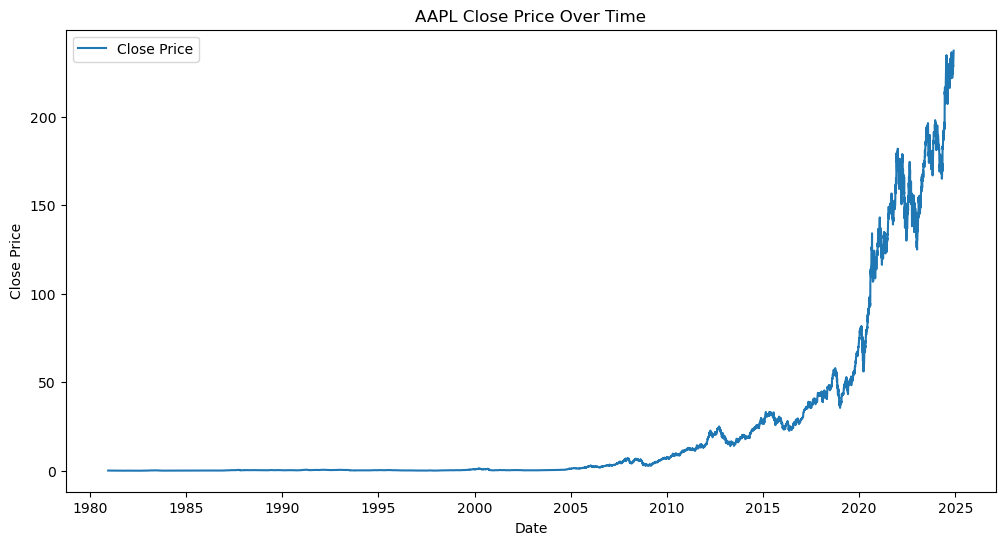

In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Visualizing the 'Close' data over time
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Close Price')
plt.title('AAPL Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [18]:
#ADF tset
adf_test = adfuller(close_data)
adf_results = {
    "ADF Statistic": adf_test[0],
    "p-value": adf_test[1],
    "Critical Values": adf_test[4],
}

adf_results

{'ADF Statistic': 4.22738126079708,
 'p-value': 1.0,
 'Critical Values': {'1%': -3.4309422510477696,
  '5%': -2.8618017424577933,
  '10%': -2.566909320386296}}

In [19]:
# Perform differencing to make the data stationary

diff_close_data = close_data.diff().dropna()

In [20]:
#ADF test
adf_test_diff = adfuller(diff_close_data)
adf_diff_results = {
    "ADF Statistic": adf_test_diff[0],
    "p-value": adf_test_diff[1],
    "Critical Values": adf_test_diff[4],
}

In [21]:
if(adf_test_diff[1] <= 0.5):
    print("True")
else:
    print("False")

True


In [22]:
adf_diff_results

{'ADF Statistic': -17.712467432806577,
 'p-value': 3.497302036118693e-30,
 'Critical Values': {'1%': -3.4309423046915986,
  '5%': -2.8618017661630577,
  '10%': -2.5669093330045536}}

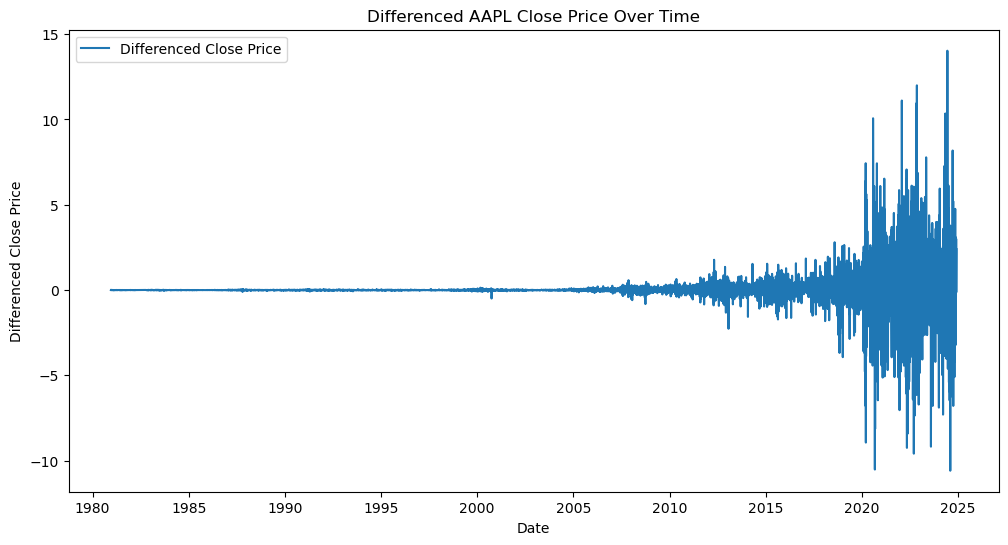

In [23]:
# Visualizing the differenced data
plt.figure(figsize=(12, 6))
plt.plot(diff_close_data, label='Differenced Close Price')
plt.title('Differenced AAPL Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

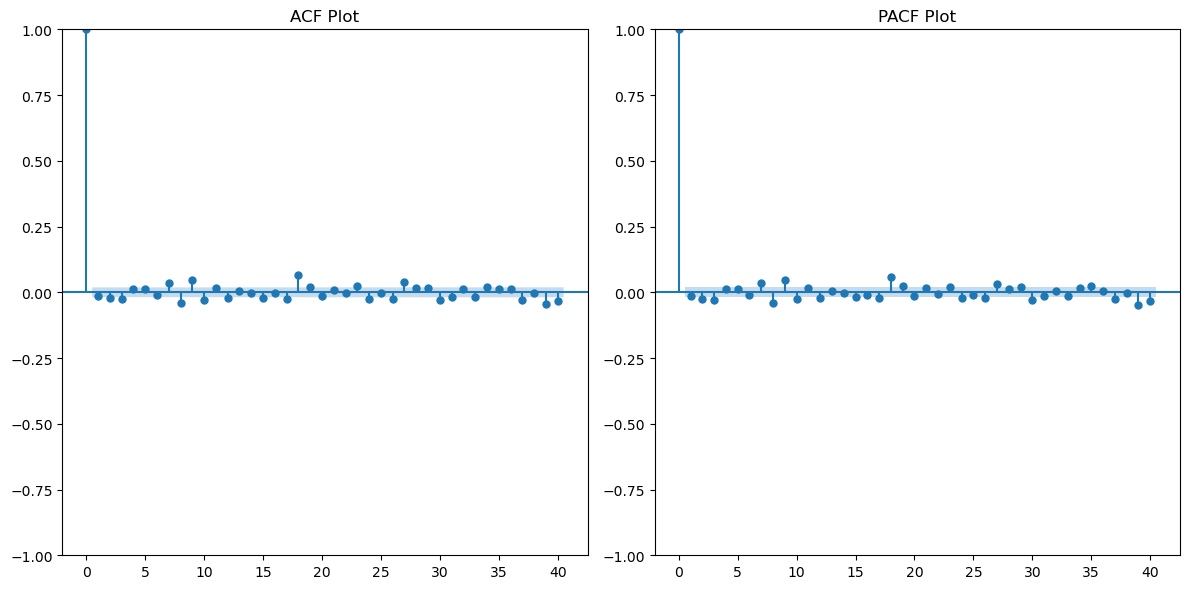

In [25]:
# ACF and PACF plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(diff_close_data, ax=plt.gca(), lags=40)
plt.title('ACF Plot')

plt.subplot(1, 2, 2)
plot_pacf(diff_close_data, ax=plt.gca(), lags=40, method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

Train size: 8867
Test size: 2217


C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 8867
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                4465.794
Date:                            Tue, 14 Jul 2026   AIC                          -8921.588
Time:                                    21:14:17   BIC                          -8886.153
Sample:                                         0   HQIC                         -8909.520
                                           - 8867                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2040      0.330      0.619      0.536      -0.442       0.850
ma.L1         -0.2152      0.329   

C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



========== SARIMA PERFORMANCE ==========
MAE  : 73.9720
MSE  : 9086.0057
RMSE : 95.3205
MAPE : 57.60%
R²   : -1.2721


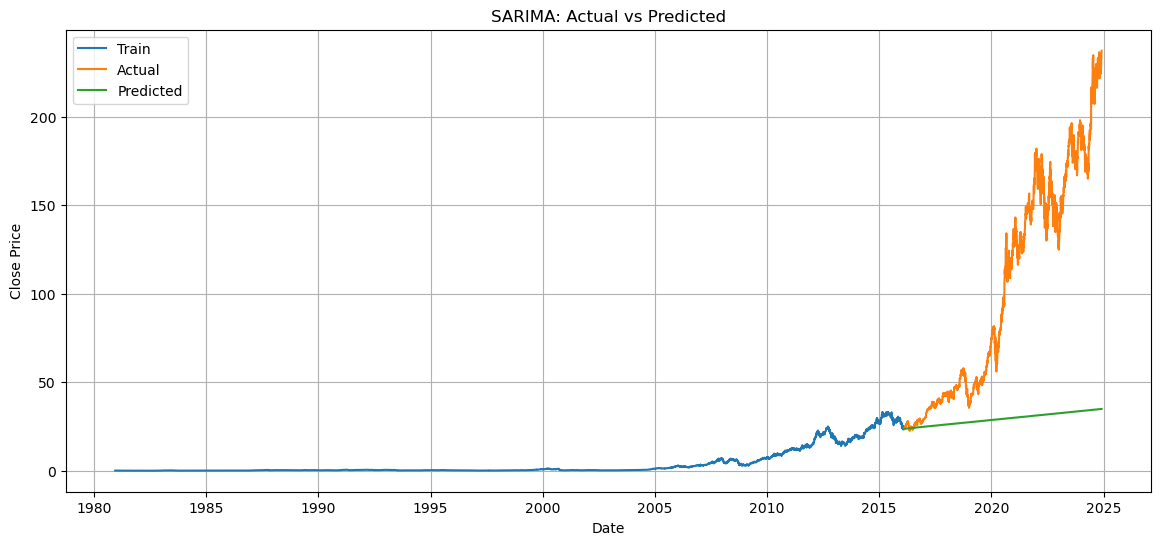

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score

# Train-Test Split
train_size = int(len(close_data) * 0.8)

train = close_data[:train_size]
test = close_data[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

seasonal_period = 12

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, seasonal_period),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print(result.summary())

predictions = result.forecast(steps=len(test))

# Align indices
predictions.index = test.index

# =========================
# Performance Metrics
# =========================
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, predictions) * 100
r2 = r2_score(test, predictions)

print("\n========== SARIMA PERFORMANCE ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(predictions.index, predictions, label="Predicted")

plt.title("SARIMA: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                11084
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -14959.045
Date:                            Tue, 14 Jul 2026   AIC                          29928.089
Time:                                    21:16:14   BIC                          29964.643
Sample:                                         0   HQIC                         29940.401
                                          - 11084                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5763      0.066      8.757      0.000       0.447       0.705
ma.L1         -0.6001      0.065   

C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Harshitha Priya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


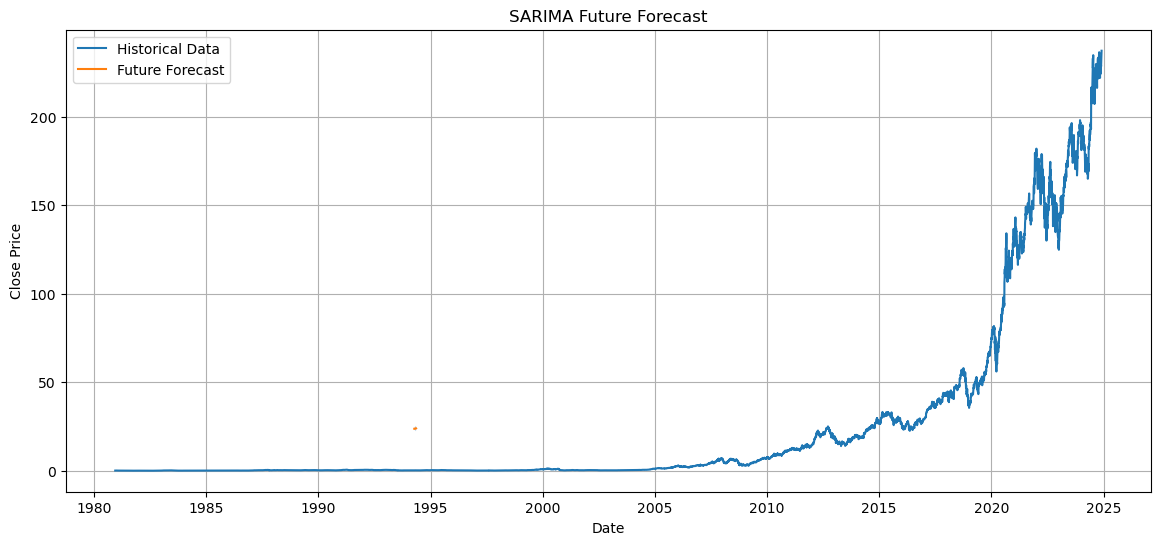

In [39]:
# Future Forecast

future_steps = 30

future_forecast = result.get_forecast(steps=future_steps)

forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

plt.figure(figsize=(14, 6))

plt.plot(close_data.index, close_data, label="Historical Data")
plt.plot(forecast_mean.index, forecast_mean, label="Future Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMA Future Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()